# Benchmark v2: 5-Way Constrained Borůvka Comparison

Compare five constrained-MST strategies + Kruskal (optimal) reference:

| # | Method | Guard | CL enforcement |
|---|--------|-------|----------------|
| 1 | **Mine – source-only** | `guard_mode=1` | Preventive bitset |
| 2 | **Mine – source+target** | `guard_mode=2` | Preventive bitset |
| 3 | **Mine – no guard** | `guard_mode=0` | Preventive bitset |
| 4 | **Rich – standard** | merge-then-fix | Linked-list pool |
| 5 | **Rich – banded** | merge-then-fix + band | Linked-list pool |
| 6 | **Kruskal (ref)** | N/A | Optimal CL-MSF |

Metrics: wall-clock time, #clusters, #rounds, MSF weight, CL violations.

## Section 1: Setup & Module Loading

We bypass the normal `fast_hdbscan.__init__` import (which triggers expensive JIT compilation 
of everything) and instead load only the submodules we need using `importlib`. This gives us 
direct access to:

- **`minimum_spanning_tree_constrained`** — Our constrained Borůvka with configurable `guard_mode`
- **`boruvka_mst_cl`** — Rich's merge-then-fix Borůvka (with optional `band_fraction`)
- **`compute_mst_from_precomputed_sparse_kruskal`** — Kruskal's algorithm (optimal CL-MSF reference)
- **CoreGraph builders** — shared infrastructure for converting pairwise distances → MRD-weighted CSR graph

In [2]:
# ── Section 1: Setup ──
import shutil, glob, sys, os, importlib, importlib.util, types, time
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances

# Clear __pycache__ so we always get fresh JIT
for d in glob.glob(os.path.join(os.getcwd(), '**', '__pycache__'), recursive=True):
    if '.venv' not in d:
        shutil.rmtree(d, ignore_errors=True)
print('Cleared __pycache__')

# ── Bypass __init__.py JIT warmup ──
_pkg_dir = os.path.join(os.getcwd(), 'fast_hdbscan')
_stub = types.ModuleType('fast_hdbscan')
_stub.__path__ = [_pkg_dir]
_stub.__package__ = 'fast_hdbscan'
sys.modules['fast_hdbscan'] = _stub

def _load(mod_name):
    spec = importlib.util.spec_from_file_location(
        f'fast_hdbscan.{mod_name}',
        os.path.join(_pkg_dir, f'{mod_name}.py'),
        submodule_search_locations=[_pkg_dir],
    )
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'fast_hdbscan.{mod_name}'] = mod
    spec.loader.exec_module(mod)
    return mod

print('Loading submodules...')
_load('variables')
_load('disjoint_set')
_load('numba_kdtree')
_load('cluster_trees')
_cg = _load('core_graph')
_load('boruvka')
_precomputed = _load('precomputed')
_load('kruskal')
_load('nndescent')
_load('hdbscan')
_bc = _load('boruvka_constrained')
print('Done.')

# ── Pull out needed functions ──
# My constrained Borůvka (with guard_mode)
minimum_spanning_tree_constrained = _bc.minimum_spanning_tree_constrained

# Core-graph builder helpers (reuse from precomputed module)
validate_precomputed_sparse_graph = _precomputed.validate_precomputed_sparse_graph
_symmetrize_min_csr = _precomputed._symmetrize_min_csr
_core_distances_csr = _precomputed._core_distances_csr
_build_core_graph_csr = _precomputed._build_core_graph_csr
CoreGraph = _cg.CoreGraph
bridge_forest_with_inf = _precomputed.bridge_forest_with_inf

# Rich's Borůvka
boruvka_mst_cl = _cg.boruvka_mst_cl

# Kruskal (optimal reference)
compute_mst_from_precomputed_sparse_kruskal = _precomputed.compute_mst_from_precomputed_sparse_kruskal

# Clustering
clusters_from_spanning_tree = sys.modules['fast_hdbscan.hdbscan'].clusters_from_spanning_tree

print('All functions loaded.')

Cleared __pycache__
Loading submodules...
Done.
All functions loaded.


## Section 2: Data Generators & CL Helpers

Five 2D point-cloud geometries with varying structure:

| Generator | Shape | # Classes | Why it's interesting |
|-----------|-------|-----------|---------------------|
| **Pinwheel** | 5 spiral arms | 5 | Non-convex, interleaved — CL constraints span arm boundaries |
| **Two moons** | 2 crescents | 2 | Classic non-linear separability test |
| **Figure eight** | 2 overlapping circles | 2 | Dense overlap zone creates many CL conflicts |
| **Chain** | 4 blobs in a line | 4 | Sequential connectivity — forces long-range merges |
| **Star** | 1 center + 5 satellites | 6 | Hub-spoke topology, central blob CL-conflicts radiate outward |

CL pairs are generated **within** the same class (intra-class constraints), so they force 
the algorithm to split what would naturally be a single cluster. The number of CL pairs 
scales as `max(3, n // 20)` — roughly 5% of the dataset size.

In [3]:
# ── Section 2: Helpers & Generators ──
SEED = 42

def make_cl_matrix(n, pairs):
    rows, cols = [], []
    for i, j in pairs:
        rows += [i, j]; cols += [j, i]
    return sp.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))

def generate_cl_pairs(y, n_pairs, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    pairs = set()
    for _ in range(n_pairs * 10):
        if len(pairs) >= n_pairs:
            break
        cls = rng.choice(classes)
        idx = np.where(y == cls)[0]
        if len(idx) < 2:
            continue
        i, j = rng.choice(idx, 2, replace=False)
        pairs.add((min(int(i), int(j)), max(int(i), int(j))))
    return sorted(pairs)

def gen_pinwheel(n, seed=SEED):
    rng = np.random.default_rng(seed)
    n_arms, Xs, ys = 5, [], []
    per_arm = n // n_arms
    for k in range(n_arms):
        m = per_arm + (1 if k < n % n_arms else 0)
        t = np.linspace(0, 1, m)
        angle = 2 * np.pi * k / n_arms
        r = 0.3 + 0.7 * t
        theta = angle + t * 1.5
        x = r * np.cos(theta) + rng.normal(0, 0.04, m)
        yy = r * np.sin(theta) + rng.normal(0, 0.04, m)
        Xs.append(np.column_stack([x, yy]))
        ys.append(np.full(m, k, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_two_moons(n, seed=SEED):
    X, y = make_moons(n_samples=n, noise=0.08, random_state=seed)
    return X.astype(np.float64), y.astype(np.int64)

def gen_figure_eight(n, seed=SEED):
    rng = np.random.default_rng(seed)
    half = n // 2
    t1 = rng.uniform(0, 2 * np.pi, half)
    t2 = rng.uniform(0, 2 * np.pi, n - half)
    X = np.vstack([
        np.column_stack([np.cos(t1) - 1, np.sin(t1)]),
        np.column_stack([np.cos(t2) + 1, np.sin(t2)]),
    ]).astype(np.float64)
    X += rng.normal(0, 0.05, X.shape)
    y = np.array([0]*half + [1]*(n-half), dtype=np.int64)
    return X, y

def gen_chain(n, seed=SEED):
    """Chain of 4 Gaussian blobs."""
    rng = np.random.default_rng(seed)
    k = 4
    per = n // k
    Xs, ys = [], []
    for i in range(k):
        m = per + (1 if i < n % k else 0)
        center = np.array([i * 2.5, 0.0])
        Xs.append(rng.normal(center, 0.5, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_star(n, seed=SEED):
    """Star: central blob + 5 satellite blobs."""
    rng = np.random.default_rng(seed)
    k = 6  # 1 center + 5 satellites
    per = n // k
    Xs, ys = [], []
    # Center
    m0 = per + (1 if 0 < n % k else 0)
    Xs.append(rng.normal([0, 0], 0.3, (m0, 2)))
    ys.append(np.full(m0, 0, dtype=np.int64))
    for i in range(1, k):
        m = per + (1 if i < n % k else 0)
        angle = 2 * np.pi * (i - 1) / (k - 1)
        center = np.array([3 * np.cos(angle), 3 * np.sin(angle)])
        Xs.append(rng.normal(center, 0.4, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

print('Helpers ready.')

Helpers ready.


## Section 3: Runner Functions

Each runner follows the same pipeline: **build CoreGraph → run MST algorithm → cluster → return metrics**.

The three runners differ only in which MST algorithm they call:

- **`run_mine`**: Calls `minimum_spanning_tree_constrained` with a `guard_mode` parameter:
  - Mode 0 (no guard) — most aggressive, multiple merges per component per round
  - Mode 1 (source-only) — blocks stale candidates after a component merges
  - Mode 2 (source+target) — also blocks fresh components from merging into recently-changed targets

- **`run_rich`**: Calls `boruvka_mst_cl` with a `band_fraction` parameter:
  - `∞` (standard) — no filtering, all candidates processed simultaneously
  - `0.05` (banded) — only edges within 5% of the lightest are allowed per round

- **`run_kruskal_ref`**: Calls `compute_mst_from_precomputed_sparse_kruskal` — processes all edges 
  in globally sorted order, giving the optimal CL-constrained MSF.

All runners time the **entire** pipeline (core graph + MST + clustering) and return:
`(time_s, n_clusters, labels, n_rounds, msf_weight)`

In [4]:
# ── Section 3: Runner functions ──
# Each returns (time_s, n_clusters, labels, n_rounds, msf_weight)

def _build_core_graph(X, ms=5):
    """Build a CoreGraph from dense feature matrix (shared by all runners)."""
    D = pairwise_distances(X, metric='euclidean').astype(np.float32)
    D_sparse = sp.csr_matrix(D)
    X_sym = _symmetrize_min_csr(D_sparse)
    nbrs, core_dists = _core_distances_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, ms)
    weights, distances, cg_indices = _build_core_graph_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, core_dists)
    return CoreGraph(weights, distances, cg_indices, X_sym.indptr), core_dists

def _edges_to_weight(edges):
    """Sum MSF edge weights (exclude +inf bridge edges)."""
    w = edges[:, 2]
    return float(np.sum(w[np.isfinite(w)]))

def _cluster_from_edges(edges, n, mcs=5):
    labels, probs, *_ = clusters_from_spanning_tree(edges, mcs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, labels


def run_mine(X, cl_indptr, cl_indices, guard_mode, ms=5, mcs=5):
    """My constrained Borůvka with configurable guard_mode."""
    t0 = time.perf_counter()
    cg, core_dists = _build_core_graph(X, ms)
    n_comp, pc, edges, n_rounds = minimum_spanning_tree_constrained(
        cg, cl_indptr, cl_indices, K=8, guard_mode=np.int32(guard_mode))
    if n_comp > 1:
        edges = bridge_forest_with_inf(edges, pc, X.shape[0])
    n_clusters, labels = _cluster_from_edges(edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, int(n_rounds), _edges_to_weight(edges)


def run_rich(X, cl_indptr, cl_indices, band_fraction=np.inf, ms=5, mcs=5):
    """Rich's Borůvka with merge-then-fix (optional banding)."""
    t0 = time.perf_counter()
    cg, core_dists = _build_core_graph(X, ms)
    n_comp, pc, edges, n_rounds = boruvka_mst_cl(
        cg, cl_indices, cl_indptr, band_fraction=band_fraction)
    if n_comp > 1:
        edges = bridge_forest_with_inf(edges, pc, X.shape[0])
    n_clusters, labels = _cluster_from_edges(edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, int(n_rounds), _edges_to_weight(edges)


def run_kruskal_ref(X, cl_sparse, ms=5, mcs=5):
    """Kruskal CL-MSF (optimal reference)."""
    t0 = time.perf_counter()
    D = pairwise_distances(X, metric='euclidean').astype(np.float64)
    D_sparse = sp.csr_matrix(D)
    mst_edges, _nbrs, _cd = compute_mst_from_precomputed_sparse_kruskal(
        D_sparse, ms, cannot_link=cl_sparse)
    n_clusters, labels = _cluster_from_edges(mst_edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, 1, _edges_to_weight(mst_edges)

print('Runners defined.')

Runners defined.


## Section 4: JIT Warmup

Numba functions are compiled on first call. We run each method once on a tiny dataset (n=50) 
so that the JIT compilation time doesn't pollute the actual benchmark measurements.

In [5]:
# ── Section 4: JIT warmup ──
print('Warming up JIT...', flush=True)
_Xw, _yw = gen_pinwheel(50)
_clp = generate_cl_pairs(_yw, 5)
_cls = make_cl_matrix(50, _clp)
_cli = np.asarray(_cls.indptr, dtype=np.int64)
_clx = np.asarray(_cls.indices, dtype=np.int32)

_ = run_mine(_Xw, _cli, _clx, guard_mode=1)
_ = run_mine(_Xw, _cli, _clx, guard_mode=2)
_ = run_mine(_Xw, _cli, _clx, guard_mode=0)
_ = run_rich(_Xw, _cli, _clx, band_fraction=np.inf)
_ = run_rich(_Xw, _cli, _clx, band_fraction=0.05)
_ = run_kruskal_ref(_Xw, _cls)
print('Warmup done.')

Warming up JIT...
Warmup done.


## Section 5: Main Benchmark — Sparse CL Setting

**CL density: `n // 20` pairs** (~5% of n). This is the "sparse" regime — relatively few 
constraints, so most merge attempts succeed and the algorithms are tested primarily on speed 
and merge-order quality.

Grid: **10 sizes × 5 geometries × 6 methods × 3 repeats** = 900 runs → 300 aggregated data points.
We record the **median** across repeats for each metric.

In [6]:
# ── Section 5: Main benchmark loop ──
SIZES = [100, 300, 500, 700, 900, 1100, 1300, 1500, 1750, 2000]
GEOMETRIES = {
    'pinwheel':     gen_pinwheel,
    'two_moons':    gen_two_moons,
    'figure_eight': gen_figure_eight,
    'chain':        gen_chain,
    'star':         gen_star,
}
N_REPEATS = 3
MS, MCS = 5, 5

# Method definitions: name -> (runner callable, call_style)
#   call_style: 'mine' -> run_mine(X, cli, clx, guard_mode=...)
#               'rich' -> run_rich(X, cli, clx, band_fraction=...)
#               'kruskal' -> run_kruskal_ref(X, cl_sparse)
METHOD_DEFS = [
    ('Mine src-only',   'mine',    dict(guard_mode=1)),
    ('Mine src+tgt',    'mine',    dict(guard_mode=2)),
    ('Mine no-guard',   'mine',    dict(guard_mode=0)),
    ('Rich standard',   'rich',    dict(band_fraction=np.inf)),
    ('Rich banded',     'rich',    dict(band_fraction=0.05)),
    ('Kruskal (ref)',   'kruskal', dict()),
]

results = []
t_start = time.perf_counter()

for geo_name, gen_fn in GEOMETRIES.items():
    for n in SIZES:
        X, y = gen_fn(n)
        n_cl = max(3, n // 20)
        cl_pairs = generate_cl_pairs(y, n_cl)
        cl_sparse = make_cl_matrix(n, cl_pairs)
        cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
        cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

        for method_name, call_style, kwargs in METHOD_DEFS:
            times, clusts, rounds_list, weights = [], [], [], []
            for _ in range(N_REPEATS):
                if call_style == 'mine':
                    t, nc, lbl, nr, w = run_mine(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                elif call_style == 'rich':
                    t, nc, lbl, nr, w = run_rich(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                else:  # kruskal
                    t, nc, lbl, nr, w = run_kruskal_ref(X, cl_sparse,
                                                         ms=MS, mcs=MCS)
                times.append(t)
                clusts.append(nc)
                rounds_list.append(nr)
                weights.append(w)

            results.append({
                'geometry': geo_name,
                'n': n,
                'method': method_name,
                'median_ms': np.median(times) * 1000,
                'n_clusters': int(np.median(clusts)),
                'n_rounds': int(np.median(rounds_list)),
                'msf_weight': np.median(weights),
            })
            print(f'{geo_name:>14} n={n:>5}  {method_name:<18} '
                  f'{np.median(times)*1000:8.1f} ms  k={int(np.median(clusts))}  '
                  f'r={int(np.median(rounds_list))}  w={np.median(weights):.1f}')

t_total = time.perf_counter() - t_start
print(f'\nDone. Total: {t_total:.1f}s  ({len(results)} data points)')

      pinwheel n=  100  Mine src-only          24.5 ms  k=2  r=3  w=21.3
      pinwheel n=  100  Mine src+tgt            7.9 ms  k=2  r=7  w=21.8
      pinwheel n=  100  Mine no-guard           6.5 ms  k=2  r=2  w=22.5
      pinwheel n=  100  Rich standard           4.6 ms  k=2  r=4  w=22.8
      pinwheel n=  100  Rich banded             9.9 ms  k=2  r=22  w=22.8
      pinwheel n=  100  Kruskal (ref)           4.8 ms  k=2  r=1  w=22.8
      pinwheel n=  300  Mine src-only          33.5 ms  k=12  r=3  w=25.9
      pinwheel n=  300  Mine src+tgt           40.5 ms  k=12  r=9  w=26.9
      pinwheel n=  300  Mine no-guard          38.1 ms  k=10  r=4  w=28.0
      pinwheel n=  300  Rich standard          26.0 ms  k=11  r=4  w=26.9
      pinwheel n=  300  Rich banded            33.5 ms  k=10  r=41  w=27.1
      pinwheel n=  300  Kruskal (ref)          31.7 ms  k=10  r=1  w=27.1
      pinwheel n=  500  Mine src-only          94.5 ms  k=14  r=5  w=32.2
      pinwheel n=  500  Mine src+tgt      

## Section 6: CL Violation Check (Sparse)

Sanity check: for the largest dataset (n=2000) in each geometry, verify that **no** CL-paired 
points end up in the same non-noise cluster. All methods should report CLEAN — CL violations 
are prevented/fixed at the MST level, so they should never leak into the final clustering.

In [7]:
# ── Section 6: CL violation check ──
print('Checking CL violations on largest size per geometry...\n')
n_check = max(SIZES)

for geo_name, gen_fn in GEOMETRIES.items():
    X, y = gen_fn(n_check)
    n_cl = max(3, n_check // 20)
    cl_pairs = generate_cl_pairs(y, n_cl)
    cl_sparse = make_cl_matrix(n_check, cl_pairs)
    cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
    cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

    print(f'--- {geo_name} (n={n_check}, CL pairs={n_cl}) ---')
    for method_name, call_style, kwargs in METHOD_DEFS:
        if call_style == 'mine':
            _, _, labels, _, _ = run_mine(X, cl_indptr, cl_indices,
                                          ms=MS, mcs=MCS, **kwargs)
        elif call_style == 'rich':
            _, _, labels, _, _ = run_rich(X, cl_indptr, cl_indices,
                                          ms=MS, mcs=MCS, **kwargs)
        else:
            _, _, labels, _, _ = run_kruskal_ref(X, cl_sparse, ms=MS, mcs=MCS)

        # Check: are any CL-paired points in the same non-noise cluster?
        violations = 0
        for i, j in cl_pairs:
            if labels[i] >= 0 and labels[i] == labels[j]:
                violations += 1
        status = 'CLEAN' if violations == 0 else f'{violations} VIOLATIONS'
        print(f'  {method_name:<18} -> {status}')
    print()

Checking CL violations on largest size per geometry...

--- pinwheel (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- two_moons (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- figure_eight (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- chain (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- star (n=2000, CL pairs=100) ---
  Mine src-only      -

## Section 7: Visualizations (Sparse CL)

Four plots showing how each method behaves as dataset size grows:

1. **Wall-clock time** — overall speed including core graph construction, MST, and clustering
2. **Borůvka rounds** — how many iterations the algorithm needs (Kruskal excluded — it's always 1 "round")
3. **MSF weight gap vs Kruskal** — positive = heavier than optimal, negative = more fragmentation (fewer finite edges)
4. **Number of clusters** — a proxy for fragmentation; more clusters = more components left disconnected

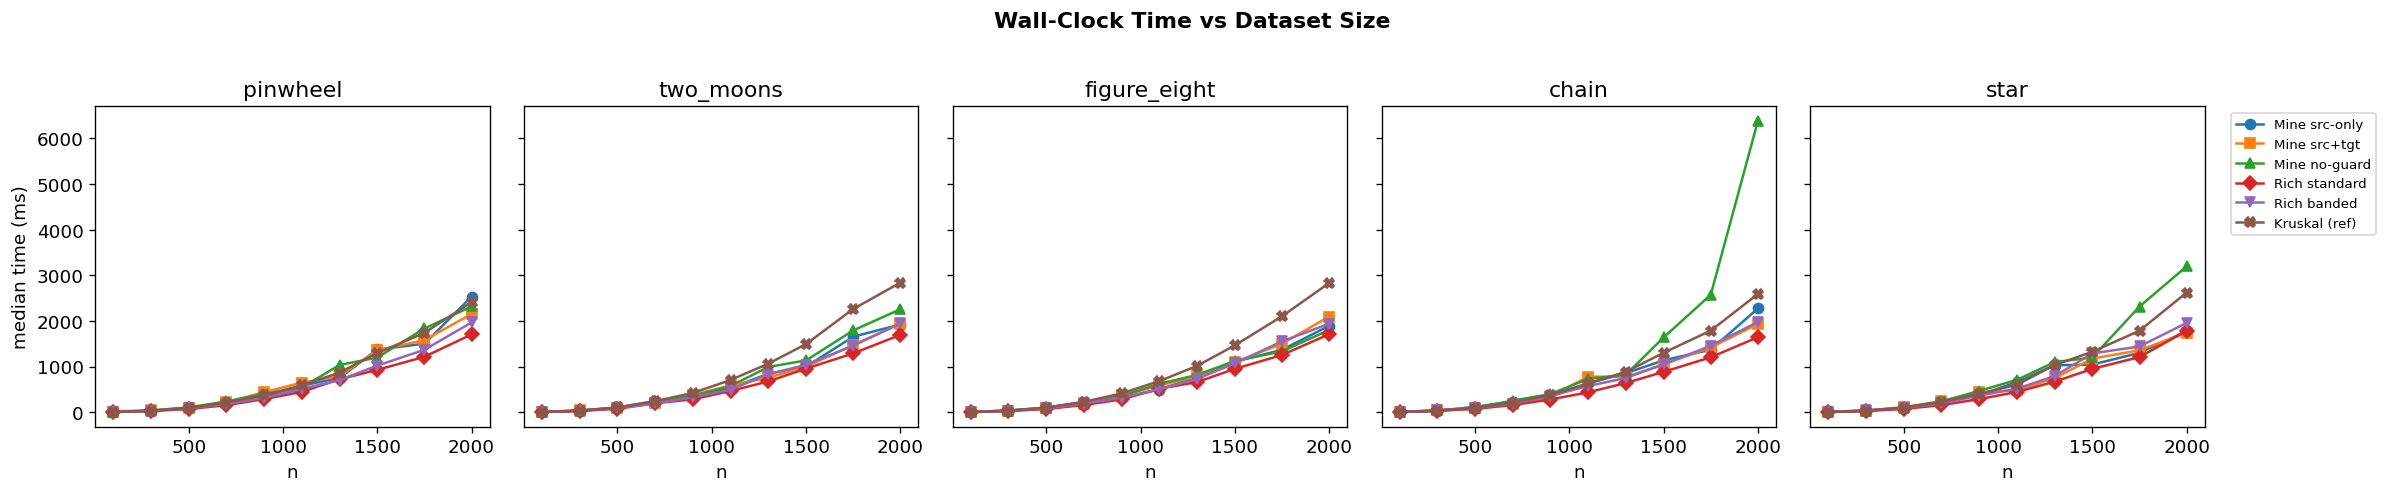

In [8]:
# ── Section 7: Visualizations ──
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

import pandas as pd
df = pd.DataFrame(results)

method_colors = {
    'Mine src-only':  '#1f77b4',
    'Mine src+tgt':   '#ff7f0e',
    'Mine no-guard':  '#2ca02c',
    'Rich standard':  '#d62728',
    'Rich banded':    '#9467bd',
    'Kruskal (ref)':  '#8c564b',
}
method_markers = {
    'Mine src-only':  'o',
    'Mine src+tgt':   's',
    'Mine no-guard':  '^',
    'Rich standard':  'D',
    'Rich banded':    'v',
    'Kruskal (ref)':  'X',
}

# ── Plot 1: Time vs n (one subplot per geometry) ──
geos = list(GEOMETRIES.keys())
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.median_ms, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('median time (ms)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Wall-Clock Time vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

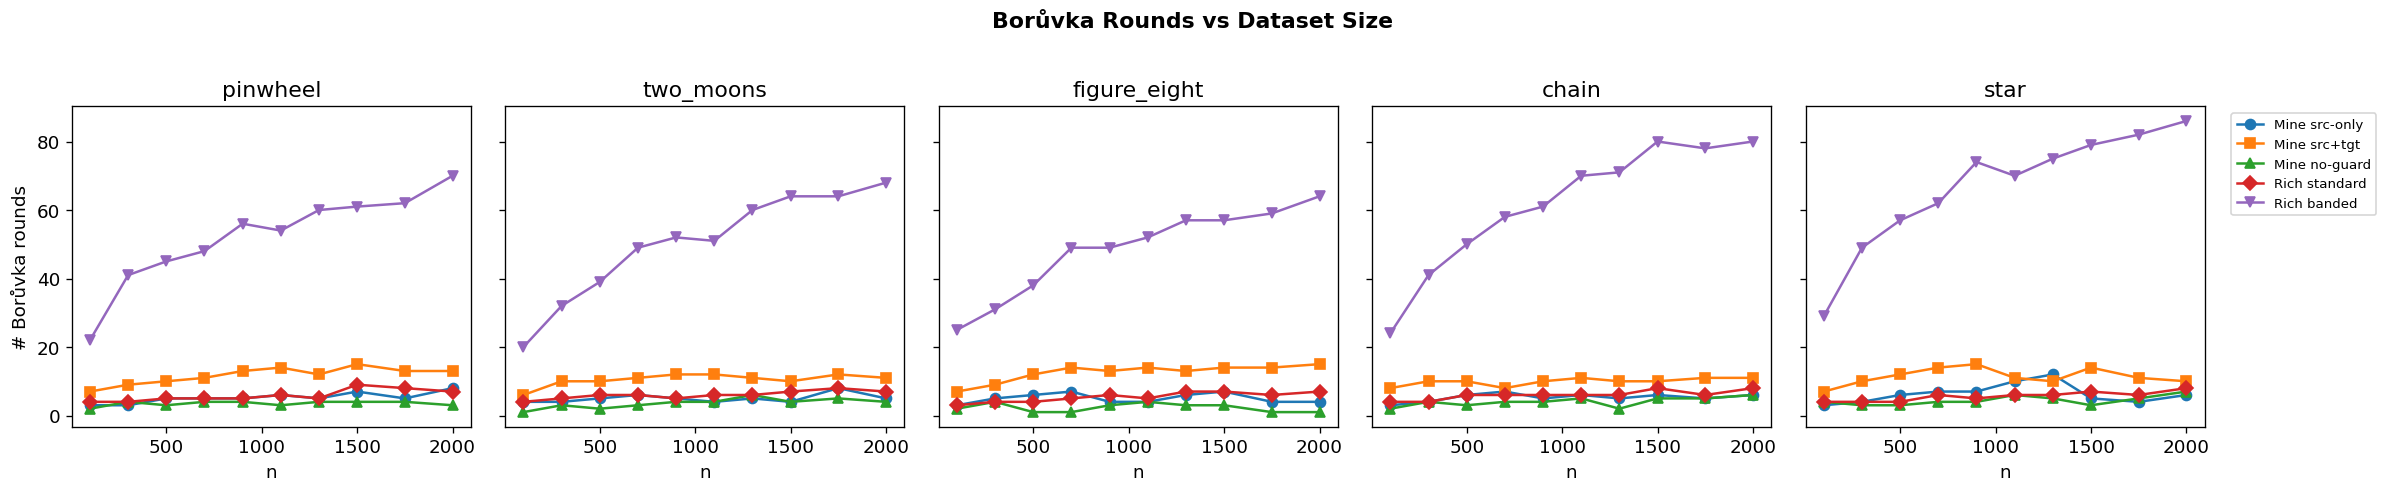

In [9]:
# ── Plot 2: Rounds vs n ──
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        if method == 'Kruskal (ref)':
            continue  # Kruskal always 1 round
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_rounds, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# Borůvka rounds')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Borůvka Rounds vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

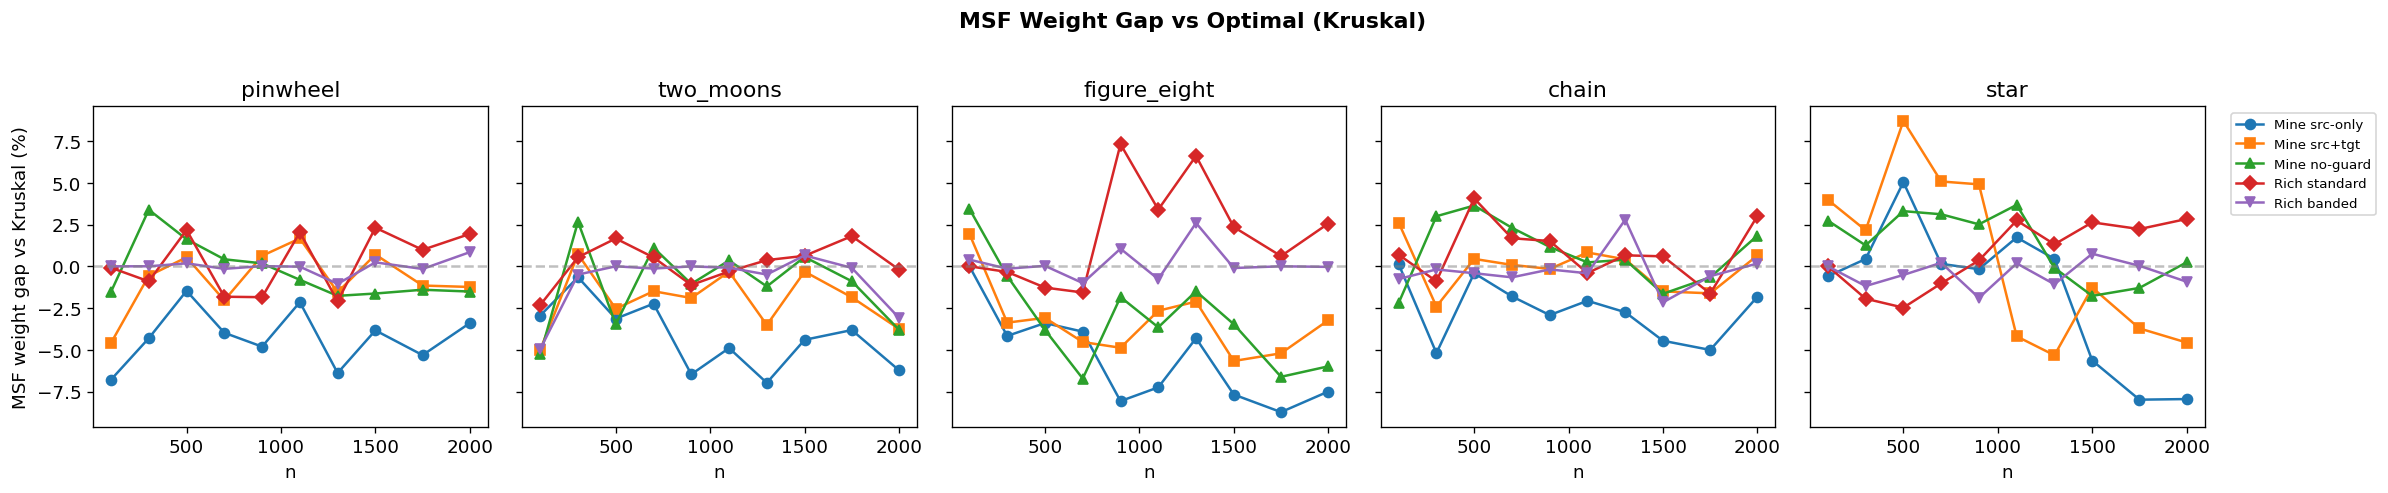

In [10]:
# ── Plot 3: MSF weight gap vs Kruskal (optimal) ──
# For each (geometry, n): weight_gap = (method_weight - kruskal_weight) / kruskal_weight * 100
kruskal_weights = df[df.method == 'Kruskal (ref)'][['geometry', 'n', 'msf_weight']].copy()
kruskal_weights.rename(columns={'msf_weight': 'kruskal_weight'}, inplace=True)
df2 = df.merge(kruskal_weights, on=['geometry', 'n'])
df2['weight_gap_pct'] = (df2.msf_weight - df2.kruskal_weight) / df2.kruskal_weight * 100

fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df2[df2.geometry == geo]
    for method in df2.method.unique():
        if method == 'Kruskal (ref)':
            continue  # gap is 0 by definition
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.weight_gap_pct, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('MSF weight gap vs Kruskal (%)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('MSF Weight Gap vs Optimal (Kruskal)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

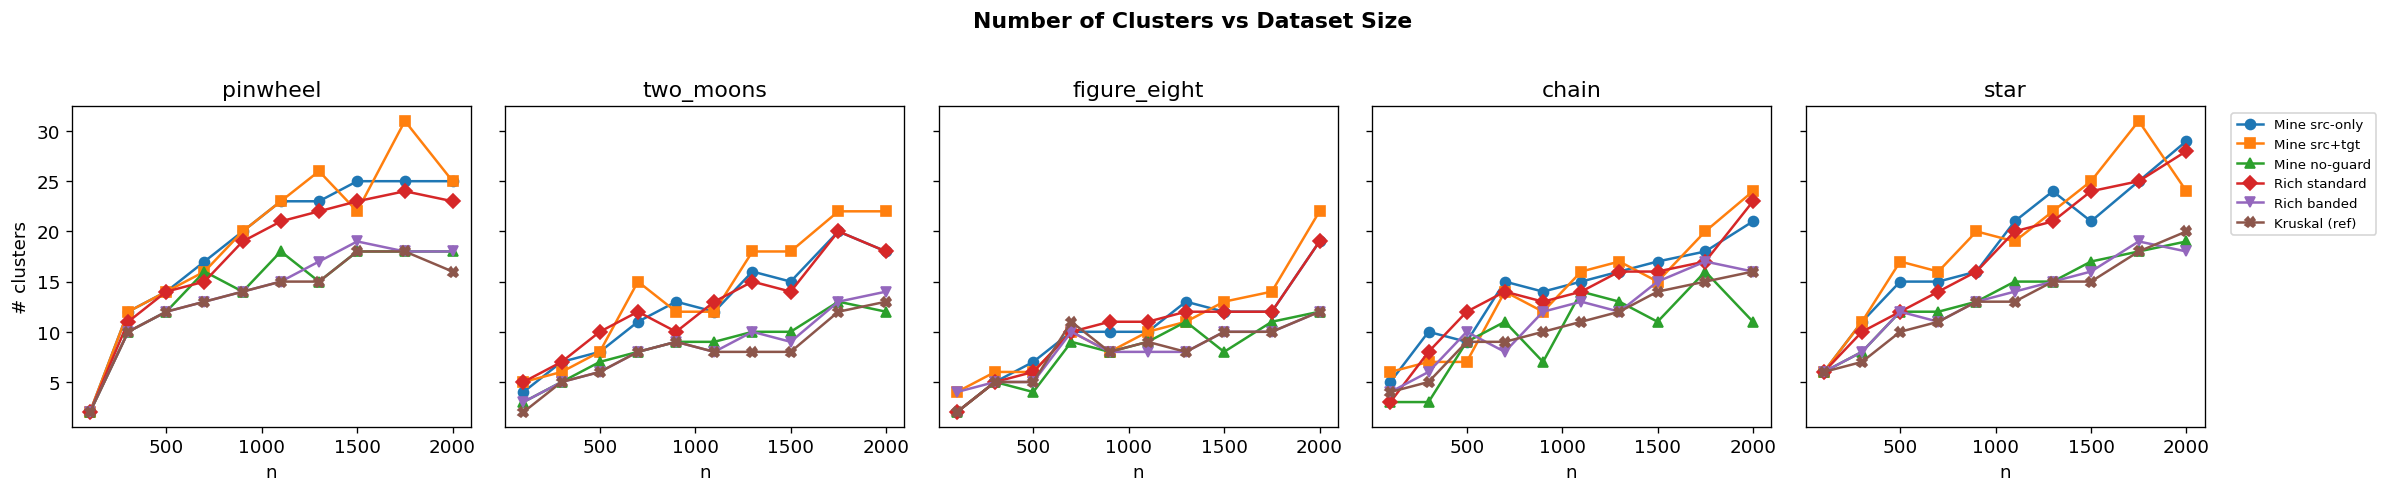

In [11]:
# ── Plot 4: Clusters vs n ──
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_clusters, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# clusters')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Number of Clusters vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 8: Summary Table (Sparse CL)

Aggregated statistics across all geometries and sizes for the sparse (`n // 20` pairs) setting.

In [12]:
# ── Section 8: Summary table ──
print('=== Summary (aggregated across all geometries) ===\n')
summary = df.groupby('method').agg(
    mean_ms=('median_ms', 'mean'),
    max_ms=('median_ms', 'max'),
    mean_rounds=('n_rounds', 'mean'),
    mean_clusters=('n_clusters', 'mean'),
    mean_weight=('msf_weight', 'mean'),
).round(2)
print(summary.to_string())

# Weight gap summary
print('\n=== MSF Weight Gap vs Kruskal (%) ===\n')
gap_summary = df2[df2.method != 'Kruskal (ref)'].groupby('method').agg(
    mean_gap=('weight_gap_pct', 'mean'),
    max_gap=('weight_gap_pct', 'max'),
    min_gap=('weight_gap_pct', 'min'),
).round(3)
print(gap_summary.to_string())

=== Summary (aggregated across all geometries) ===

               mean_ms   max_ms  mean_rounds  mean_clusters  mean_weight
method                                                                  
Kruskal (ref)   835.72  2840.96         1.00          10.50       104.45
Mine no-guard   878.43  6383.70         3.56          10.78       104.37
Mine src+tgt    671.88  2155.11        11.20          15.24       103.38
Mine src-only   680.19  2534.07         5.38          14.66       100.84
Rich banded     645.71  1978.08        55.50          10.96       104.18
Rich standard   557.20  1786.55         5.76          14.20       105.56

=== MSF Weight Gap vs Kruskal (%) ===

               mean_gap  max_gap  min_gap
method                                   
Mine no-guard    -0.461    3.679   -6.727
Mine src+tgt     -1.107    8.706   -5.672
Mine src-only    -3.603    5.042   -8.734
Rich banded      -0.273    2.793   -4.955
Rich standard     0.798    7.317   -2.477


---

# Part 2: Dense CL Setting

The sparse benchmark above uses `n // 20` CL pairs (~5% of n). How do the methods behave 
when constraints are **4× denser** at `n // 5` (~20% of n)?

Denser constraints mean:
- More merge attempts will be **blocked** by CL checks
- **Preventive** methods (ours) must do more cross-walks per merge
- **Merge-then-fix** methods (Rich's) will find more transitive violations to repair
- **Kruskal** will skip more edges in its sorted scan
- All methods should produce **more clusters** (more forced separations)

This stress-tests each method's CL-handling efficiency under heavy constraint load.

In [13]:
# ── Dense CL benchmark loop ──
# Same grid as sparse but with n//5 CL pairs (4× denser)
CL_DIVISOR_DENSE = 5  # n // 5 pairs ≈ 20% of n

results_dense = []
t_start_d = time.perf_counter()

for geo_name, gen_fn in GEOMETRIES.items():
    for n in SIZES:
        X, y = gen_fn(n)
        n_cl = max(3, n // CL_DIVISOR_DENSE)
        cl_pairs = generate_cl_pairs(y, n_cl)
        cl_sparse = make_cl_matrix(n, cl_pairs)
        cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
        cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

        for method_name, call_style, kwargs in METHOD_DEFS:
            times, clusts, rounds_list, weights = [], [], [], []
            for _ in range(N_REPEATS):
                if call_style == 'mine':
                    t, nc, lbl, nr, w = run_mine(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                elif call_style == 'rich':
                    t, nc, lbl, nr, w = run_rich(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                else:
                    t, nc, lbl, nr, w = run_kruskal_ref(X, cl_sparse,
                                                         ms=MS, mcs=MCS)
                times.append(t)
                clusts.append(nc)
                rounds_list.append(nr)
                weights.append(w)

            results_dense.append({
                'geometry': geo_name,
                'n': n,
                'method': method_name,
                'median_ms': np.median(times) * 1000,
                'n_clusters': int(np.median(clusts)),
                'n_rounds': int(np.median(rounds_list)),
                'msf_weight': np.median(weights),
            })
            print(f'{geo_name:>14} n={n:>5}  {method_name:<18} '
                  f'{np.median(times)*1000:8.1f} ms  k={int(np.median(clusts))}  '
                  f'r={int(np.median(rounds_list))}  w={np.median(weights):.1f}')

t_total_d = time.perf_counter() - t_start_d
print(f'\nDone (dense CL). Total: {t_total_d:.1f}s  ({len(results_dense)} data points)')

      pinwheel n=  100  Mine src-only          17.4 ms  k=2  r=3  w=22.0
      pinwheel n=  100  Mine src+tgt           15.9 ms  k=4  r=6  w=22.1
      pinwheel n=  100  Mine no-guard           8.4 ms  k=2  r=3  w=24.2
      pinwheel n=  100  Rich standard          17.6 ms  k=2  r=4  w=22.7
      pinwheel n=  100  Rich banded            19.0 ms  k=3  r=22  w=22.6
      pinwheel n=  100  Kruskal (ref)           6.0 ms  k=2  r=1  w=22.9
      pinwheel n=  300  Mine src-only          56.5 ms  k=17  r=5  w=27.2
      pinwheel n=  300  Mine src+tgt           76.4 ms  k=17  r=9  w=28.6
      pinwheel n=  300  Mine no-guard          51.5 ms  k=13  r=3  w=28.5
      pinwheel n=  300  Rich standard          53.3 ms  k=16  r=5  w=29.4
      pinwheel n=  300  Rich banded            46.1 ms  k=15  r=42  w=28.5
      pinwheel n=  300  Kruskal (ref)          39.0 ms  k=14  r=1  w=28.2
      pinwheel n=  500  Mine src-only         118.0 ms  k=20  r=6  w=33.8
      pinwheel n=  500  Mine src+tgt      

## CL Violation Check (Dense)

Same check as before but with the denser CL constraint set.

In [14]:
# ── CL violation check (dense) ──
print('Checking CL violations (dense) on largest size per geometry...\n')
n_check = max(SIZES)

for geo_name, gen_fn in GEOMETRIES.items():
    X, y = gen_fn(n_check)
    n_cl = max(3, n_check // CL_DIVISOR_DENSE)
    cl_pairs_d = generate_cl_pairs(y, n_cl)
    cl_sparse_d = make_cl_matrix(n_check, cl_pairs_d)
    cl_indptr_d = np.asarray(cl_sparse_d.indptr, dtype=np.int64)
    cl_indices_d = np.asarray(cl_sparse_d.indices, dtype=np.int32)

    print(f'--- {geo_name} (n={n_check}, CL pairs={n_cl}) ---')
    for method_name, call_style, kwargs in METHOD_DEFS:
        if call_style == 'mine':
            _, _, labels, _, _ = run_mine(X, cl_indptr_d, cl_indices_d,
                                          ms=MS, mcs=MCS, **kwargs)
        elif call_style == 'rich':
            _, _, labels, _, _ = run_rich(X, cl_indptr_d, cl_indices_d,
                                          ms=MS, mcs=MCS, **kwargs)
        else:
            _, _, labels, _, _ = run_kruskal_ref(X, cl_sparse_d, ms=MS, mcs=MCS)

        violations = 0
        for i, j in cl_pairs_d:
            if labels[i] >= 0 and labels[i] == labels[j]:
                violations += 1
        status = 'CLEAN' if violations == 0 else f'{violations} VIOLATIONS'
        print(f'  {method_name:<18} -> {status}')
    print()

Checking CL violations (dense) on largest size per geometry...

--- pinwheel (n=2000, CL pairs=400) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- two_moons (n=2000, CL pairs=400) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- figure_eight (n=2000, CL pairs=400) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- chain (n=2000, CL pairs=400) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- star (n=2000, CL pairs=400) ---
  Mine src-onl

## Visualizations (Dense CL)

Same four plots as the sparse setting, now with 4× more CL constraints.

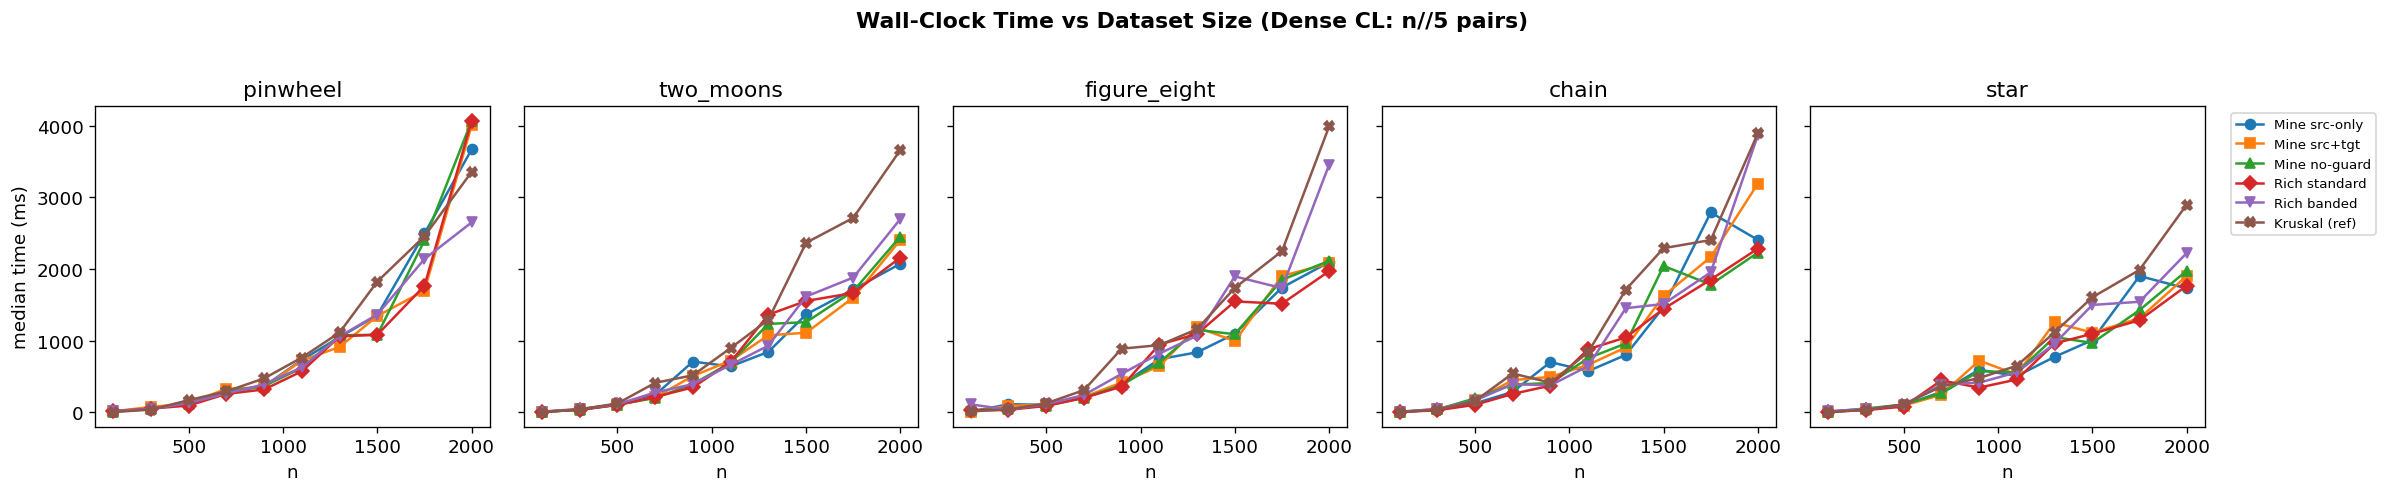

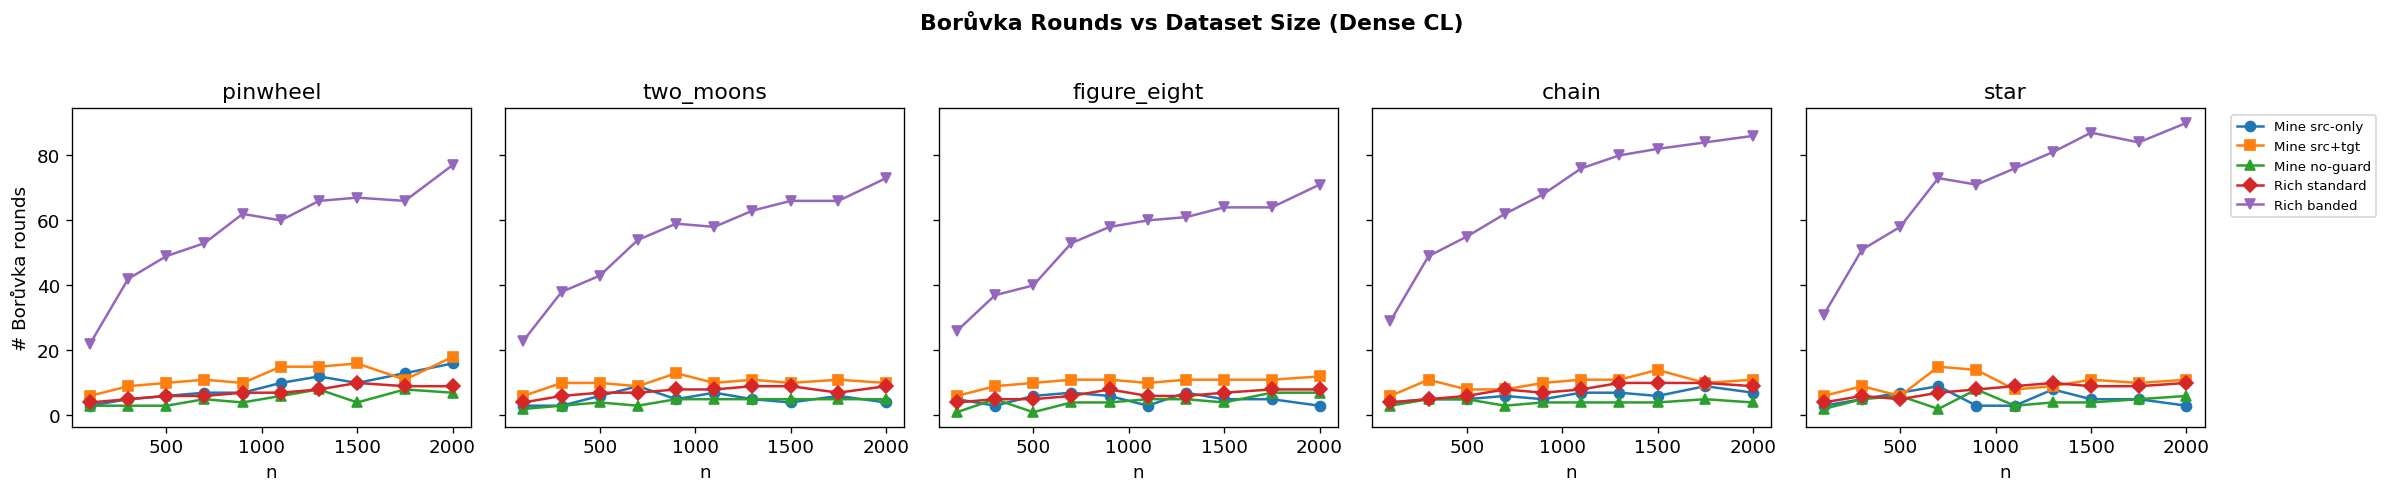

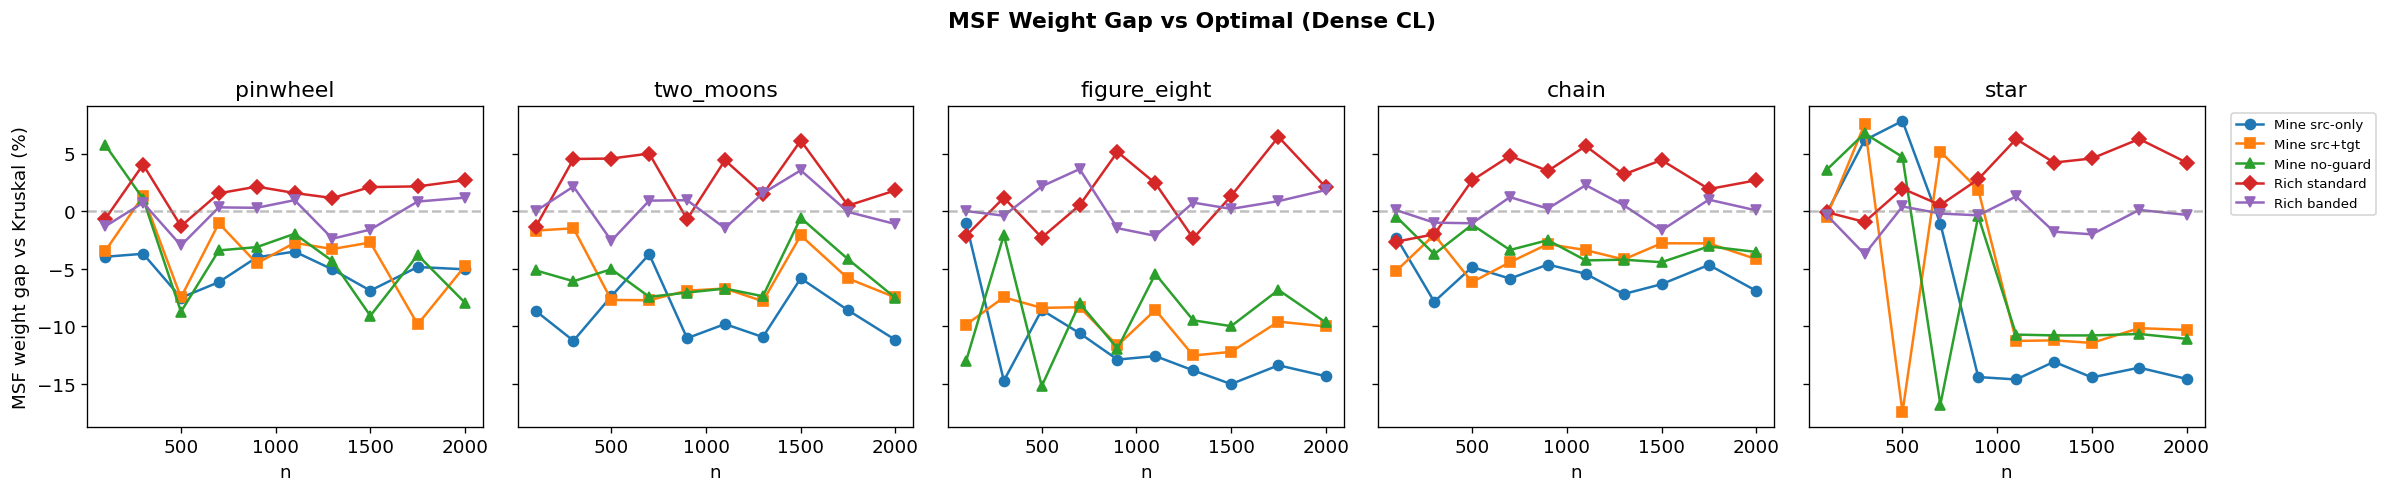

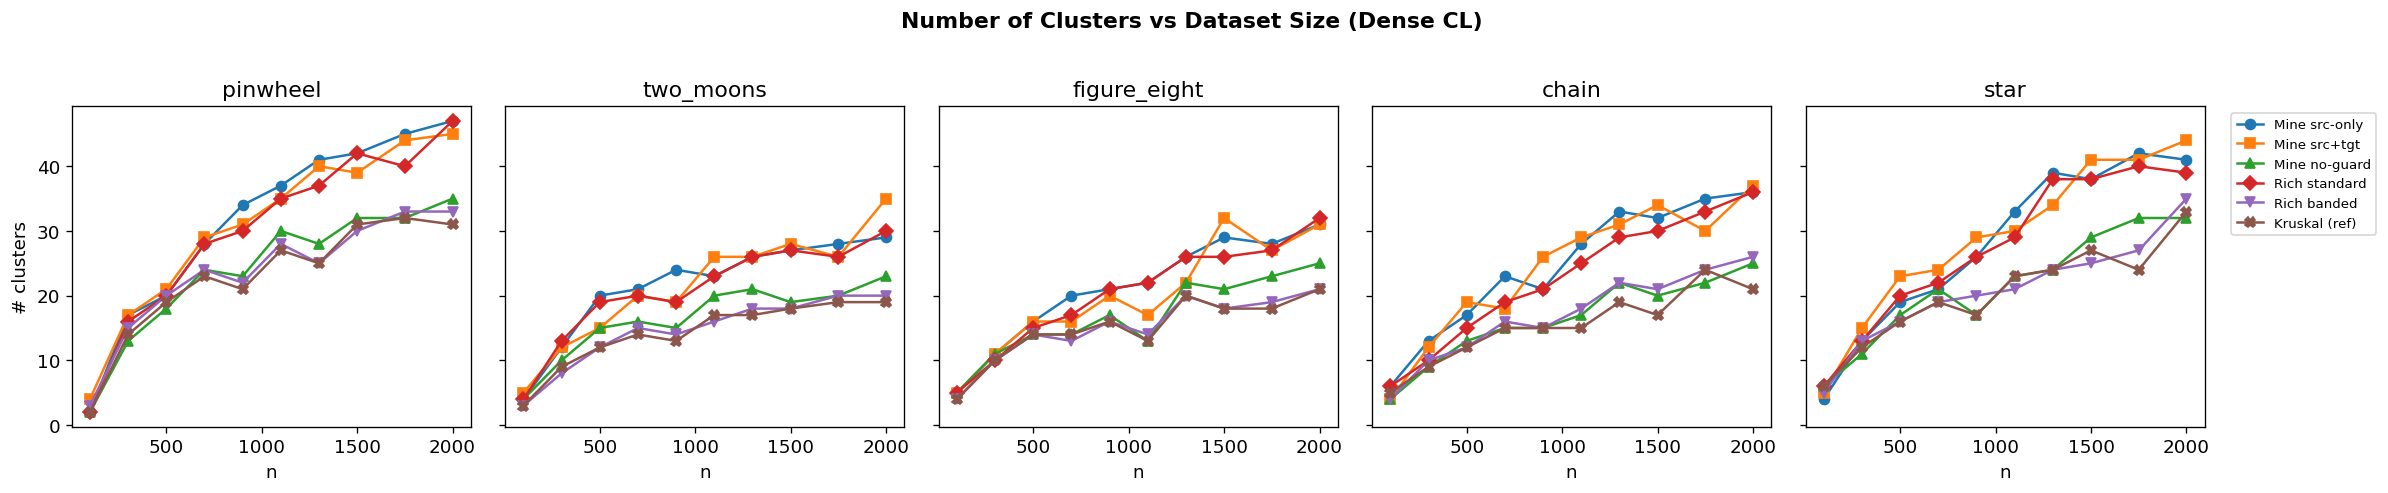

In [15]:
# ── Dense CL: All 4 plots ──
df_d = pd.DataFrame(results_dense)

# Plot 1: Time vs n (dense)
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df_d[df_d.geometry == geo]
    for method in df_d.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.median_ms, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('median time (ms)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Wall-Clock Time vs Dataset Size (Dense CL: n//5 pairs)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Plot 2: Rounds vs n (dense)
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df_d[df_d.geometry == geo]
    for method in df_d.method.unique():
        if method == 'Kruskal (ref)':
            continue
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_rounds, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# Borůvka rounds')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Borůvka Rounds vs Dataset Size (Dense CL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Plot 3: Weight gap (dense)
kw_d = df_d[df_d.method == 'Kruskal (ref)'][['geometry', 'n', 'msf_weight']].copy()
kw_d.rename(columns={'msf_weight': 'kruskal_weight'}, inplace=True)
df2_d = df_d.merge(kw_d, on=['geometry', 'n'])
df2_d['weight_gap_pct'] = (df2_d.msf_weight - df2_d.kruskal_weight) / df2_d.kruskal_weight * 100

fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df2_d[df2_d.geometry == geo]
    for method in df2_d.method.unique():
        if method == 'Kruskal (ref)':
            continue
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.weight_gap_pct, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('MSF weight gap vs Kruskal (%)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('MSF Weight Gap vs Optimal (Dense CL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Plot 4: Clusters vs n (dense)
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df_d[df_d.geometry == geo]
    for method in df_d.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_clusters, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# clusters')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Number of Clusters vs Dataset Size (Dense CL)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary Table (Dense CL)

In [16]:
# ── Summary table (dense CL) ──
print('=== Summary — Dense CL (n//5 pairs, aggregated across all geometries) ===\n')
summary_d = df_d.groupby('method').agg(
    mean_ms=('median_ms', 'mean'),
    max_ms=('median_ms', 'max'),
    mean_rounds=('n_rounds', 'mean'),
    mean_clusters=('n_clusters', 'mean'),
    mean_weight=('msf_weight', 'mean'),
).round(2)
print(summary_d.to_string())

print('\n=== MSF Weight Gap vs Kruskal (%) — Dense CL ===\n')
gap_summary_d = df2_d[df2_d.method != 'Kruskal (ref)'].groupby('method').agg(
    mean_gap=('weight_gap_pct', 'mean'),
    max_gap=('weight_gap_pct', 'max'),
    min_gap=('weight_gap_pct', 'min'),
).round(3)
print(gap_summary_d.to_string())

=== Summary — Dense CL (n//5 pairs, aggregated across all geometries) ===

               mean_ms   max_ms  mean_rounds  mean_clusters  mean_weight
method                                                                  
Kruskal (ref)  1111.61  3991.89         1.00          17.34       110.31
Mine no-guard   833.32  4065.84         4.44          18.78       103.75
Mine src+tgt    840.04  4007.16        10.44          24.80       103.68
Mine src-only   828.25  3668.77         6.06          25.12       101.15
Rich banded     911.41  3869.20        60.28          17.98       110.27
Rich standard   800.95  4066.53         7.24          24.00       113.54

=== MSF Weight Gap vs Kruskal (%) — Dense CL ===

               mean_gap  max_gap  min_gap
method                                   
Mine no-guard    -5.424    6.761  -16.787
Mine src+tgt     -5.764    7.562  -17.441
Mine src-only    -7.675    7.835  -15.007
Rich banded       0.005    3.657   -3.730
Rich standard     2.163    6.451   -2.

## Sparse vs Dense: Side-by-Side Comparison

How does each method's behavior shift when CL density increases 4×?

In [17]:
# ── Sparse vs Dense comparison ──
sparse_summary = df.groupby('method').agg(
    sparse_ms=('median_ms', 'mean'),
    sparse_rounds=('n_rounds', 'mean'),
    sparse_clusters=('n_clusters', 'mean'),
).round(2)

dense_summary = df_d.groupby('method').agg(
    dense_ms=('median_ms', 'mean'),
    dense_rounds=('n_rounds', 'mean'),
    dense_clusters=('n_clusters', 'mean'),
).round(2)

comparison = sparse_summary.join(dense_summary)
comparison['time_ratio'] = (comparison.dense_ms / comparison.sparse_ms).round(2)
comparison['cluster_ratio'] = (comparison.dense_clusters / comparison.sparse_clusters).round(2)

# Weight gap comparison
sparse_gap = df2[df2.method != 'Kruskal (ref)'].groupby('method')['weight_gap_pct'].mean().round(3)
dense_gap = df2_d[df2_d.method != 'Kruskal (ref)'].groupby('method')['weight_gap_pct'].mean().round(3)
comparison['sparse_wt_gap%'] = sparse_gap
comparison['dense_wt_gap%'] = dense_gap

print('=== Sparse (n//20) vs Dense (n//5) Comparison ===\n')
print(comparison.to_string())
print('\ntime_ratio = dense_ms / sparse_ms  (>1 means denser CL is slower)')
print('cluster_ratio = dense_clusters / sparse_clusters  (>1 means more fragmentation)')

=== Sparse (n//20) vs Dense (n//5) Comparison ===

               sparse_ms  sparse_rounds  sparse_clusters  dense_ms  dense_rounds  dense_clusters  time_ratio  cluster_ratio  sparse_wt_gap%  dense_wt_gap%
method                                                                                                                                                    
Kruskal (ref)     835.72           1.00            10.50   1111.61          1.00           17.34        1.33           1.65             NaN            NaN
Mine no-guard     878.43           3.56            10.78    833.32          4.44           18.78        0.95           1.74          -0.461         -5.424
Mine src+tgt      671.88          11.20            15.24    840.04         10.44           24.80        1.25           1.63          -1.107         -5.764
Mine src-only     680.19           5.38            14.66    828.25          6.06           25.12        1.22           1.71          -3.603         -7.675
Rich banded       6

---

## Cluster Health Check — Min / Max Cluster Sizes

The summary tables above report **number of clusters**, but that doesn't tell us whether those
clusters are *healthy*. A method could report 15 clusters while hiding the fact that 10 of them
are singletons.

Below we re-run every method **once** at the largest size (n = 2000) for each geometry, collect
the actual label assignments, and compute:

| Metric | Meaning |
|--------|---------|
| **min_size** | Smallest cluster (excluding noise label −1). Singletons = 1 |
| **max_size** | Largest cluster |
| **median_size** | Median cluster size |
| **n_noise** | Points labelled −1 (not assigned to any cluster) |
| **n_singletons** | Clusters with exactly 1 point |
| **pct_noise** | % of points labelled noise |

We do this for **both** sparse (n//20) and dense (n//5) CL settings.

In [18]:
# ── Cluster Health Check ──
# Re-run each method once at n=2000 for every geometry, both CL densities.
# Collect labels → compute cluster-size statistics.

from collections import Counter

N_HEALTH = 2000  # fixed size for health check

def cluster_size_stats(labels):
    """Compute cluster-size stats from a label array (noise = -1)."""
    counts = Counter(labels)
    n_noise = counts.pop(-1, 0)
    if len(counts) == 0:
        return dict(n_clusters=0, min_size=0, max_size=0, median_size=0,
                    n_noise=int(n_noise), n_singletons=0,
                    pct_noise=round(100 * n_noise / len(labels), 1))
    sizes = sorted(counts.values())
    return dict(
        n_clusters=len(sizes),
        min_size=int(sizes[0]),
        max_size=int(sizes[-1]),
        median_size=int(np.median(sizes)),
        n_noise=int(n_noise),
        n_singletons=int(sum(1 for s in sizes if s == 1)),
        pct_noise=round(100 * n_noise / len(labels), 1),
    )

health_rows = []

for cl_label, cl_div in [('sparse (n//20)', 20), ('dense (n//5)', 5)]:
    for geo_name, gen_fn in GEOMETRIES.items():
        X, y = gen_fn(N_HEALTH)
        n_cl = max(3, N_HEALTH // cl_div)
        cl_pairs = generate_cl_pairs(y, n_cl)
        cl_sparse = make_cl_matrix(N_HEALTH, cl_pairs)
        cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
        cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

        for method_name, call_style, kwargs in METHOD_DEFS:
            if call_style == 'mine':
                _, _, lbl, _, _ = run_mine(X, cl_indptr, cl_indices,
                                           ms=MS, mcs=MCS, **kwargs)
            elif call_style == 'rich':
                _, _, lbl, _, _ = run_rich(X, cl_indptr, cl_indices,
                                           ms=MS, mcs=MCS, **kwargs)
            else:
                _, _, lbl, _, _ = run_kruskal_ref(X, cl_sparse, ms=MS, mcs=MCS)

            stats = cluster_size_stats(lbl)
            stats['cl_setting'] = cl_label
            stats['geometry'] = geo_name
            stats['method'] = method_name
            health_rows.append(stats)
            print(f'{cl_label}  {geo_name:>14}  {method_name:<18}  '
                  f'k={stats["n_clusters"]:>3}  '
                  f'min={stats["min_size"]:>4}  max={stats["max_size"]:>4}  '
                  f'median={stats["median_size"]:>4}  '
                  f'noise={stats["n_noise"]:>4} ({stats["pct_noise"]}%)  '
                  f'singletons={stats["n_singletons"]}')

health_df = pd.DataFrame(health_rows)
print(f'\nDone — {len(health_rows)} label arrays analysed.')

sparse (n//20)        pinwheel  Mine src-only       k= 25  min=  19  max= 195  median=  73  noise=   8 (0.4%)  singletons=0
sparse (n//20)        pinwheel  Mine src+tgt        k= 25  min=  14  max= 136  median=  85  noise=  13 (0.7%)  singletons=0
sparse (n//20)        pinwheel  Mine no-guard       k= 18  min=  42  max= 187  median= 106  noise=   9 (0.5%)  singletons=0
sparse (n//20)        pinwheel  Rich standard       k= 23  min=  19  max= 195  median=  82  noise=   5 (0.2%)  singletons=0
sparse (n//20)        pinwheel  Rich banded         k= 18  min=  10  max= 238  median=  94  noise=   7 (0.3%)  singletons=0
sparse (n//20)        pinwheel  Kruskal (ref)       k= 16  min=  68  max= 237  median= 106  noise=   7 (0.3%)  singletons=0
sparse (n//20)       two_moons  Mine src-only       k= 18  min=  44  max= 258  median=  94  noise=   1 (0.1%)  singletons=0
sparse (n//20)       two_moons  Mine src+tgt        k= 22  min=  11  max= 264  median=  74  noise=  10 (0.5%)  singletons=0
sparse (

In [19]:
# ── Cluster health summary tables ──
for setting in ['sparse (n//20)', 'dense (n//5)']:
    sub = health_df[health_df.cl_setting == setting]
    agg = sub.groupby('method').agg(
        avg_clusters=('n_clusters', 'mean'),
        min_of_mins=('min_size', 'min'),
        avg_min=('min_size', 'mean'),
        avg_max=('max_size', 'mean'),
        max_of_maxes=('max_size', 'max'),
        avg_median=('median_size', 'mean'),
        total_singletons=('n_singletons', 'sum'),
        avg_noise_pct=('pct_noise', 'mean'),
    ).round(1)
    print(f'=== Cluster Health — {setting}, n={N_HEALTH} (across {len(GEOMETRIES)} geometries) ===\n')
    print(agg.to_string())
    print()

# Flag any singletons
total_sing = health_df['n_singletons'].sum()
if total_sing == 0:
    print('✅ No singletons found in any method/geometry/CL setting.')
else:
    print(f'⚠️  Total singletons found: {total_sing}')
    sing_rows = health_df[health_df.n_singletons > 0][
        ['cl_setting', 'geometry', 'method', 'n_singletons', 'min_size']]
    print(sing_rows.to_string(index=False))

=== Cluster Health — sparse (n//20), n=2000 (across 5 geometries) ===

               avg_clusters  min_of_mins  avg_min  avg_max  max_of_maxes  avg_median  total_singletons  avg_noise_pct
method                                                                                                               
Kruskal (ref)          15.4           10     34.8    303.6           356       113.6                 0            1.5
Mine no-guard          14.4           10     29.4    431.6           980       134.4                 0            0.7
Mine src+tgt           23.4           10     14.2    235.4           322        74.8                 0            1.2
Mine src-only          22.4           16     22.2    217.2           270        80.4                 0            1.0
Rich banded            15.6           10     22.6    290.6           351       122.8                 0            1.1
Rich standard          22.2           11     20.4    218.8           270        79.6                 0 

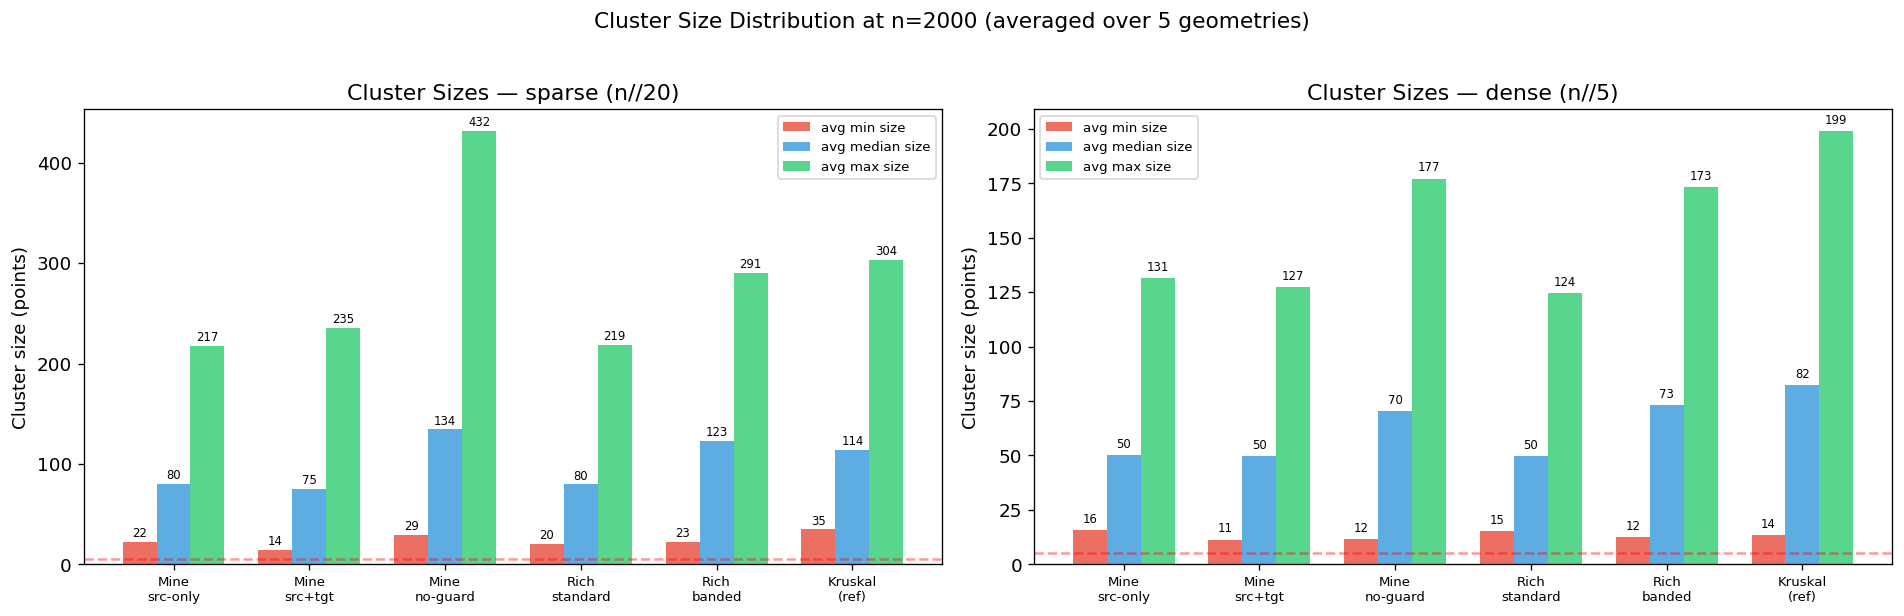

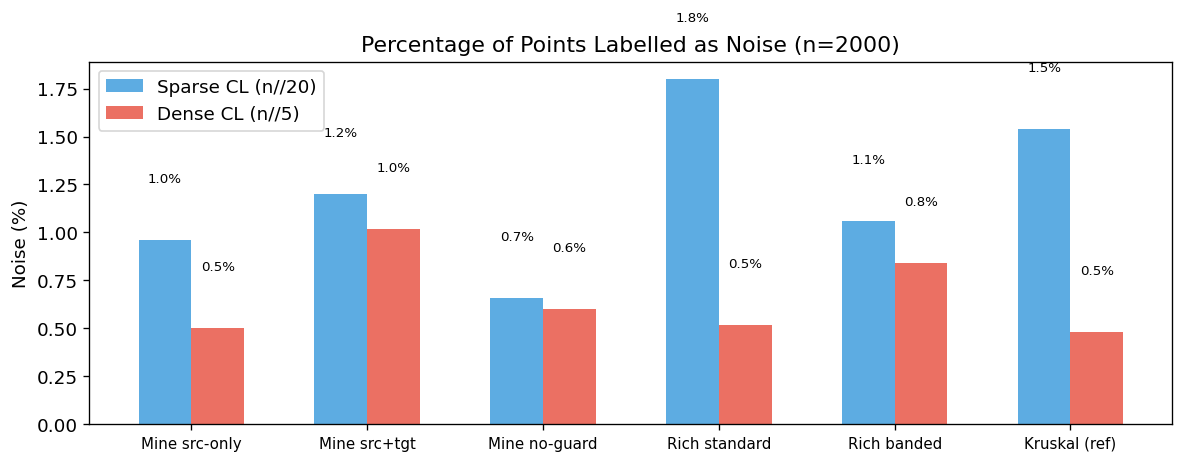

In [20]:
# ── Cluster size distribution visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, setting in zip(axes, ['sparse (n//20)', 'dense (n//5)']):
    sub = health_df[health_df.cl_setting == setting]
    methods = [m for m, _, _ in METHOD_DEFS]

    # For each method, collect all cluster min_size values across geometries
    mins = [sub[sub.method == m]['min_size'].values for m in methods]
    maxes = [sub[sub.method == m]['max_size'].values for m in methods]
    medians = [sub[sub.method == m]['median_size'].values for m in methods]

    x = np.arange(len(methods))
    width = 0.25

    bars_min = ax.bar(x - width, [np.mean(v) for v in mins], width,
                      label='avg min size', color='#e74c3c', alpha=0.8)
    bars_med = ax.bar(x,         [np.mean(v) for v in medians], width,
                      label='avg median size', color='#3498db', alpha=0.8)
    bars_max = ax.bar(x + width, [np.mean(v) for v in maxes], width,
                      label='avg max size', color='#2ecc71', alpha=0.8)

    # Add value labels on bars
    for bars in [bars_min, bars_med, bars_max]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 2,
                        f'{h:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in methods], fontsize=8)
    ax.set_ylabel('Cluster size (points)')
    ax.set_title(f'Cluster Sizes — {setting}')
    ax.legend(fontsize=8)
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.4, label='min_cluster_size=5')

fig.suptitle(f'Cluster Size Distribution at n={N_HEALTH} (averaged over {len(GEOMETRIES)} geometries)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Also show noise percentage comparison
fig2, ax2 = plt.subplots(figsize=(10, 4))
methods = [m for m, _, _ in METHOD_DEFS]
sparse_noise = [health_df[(health_df.cl_setting == 'sparse (n//20)') &
                           (health_df.method == m)]['pct_noise'].mean() for m in methods]
dense_noise = [health_df[(health_df.cl_setting == 'dense (n//5)') &
                          (health_df.method == m)]['pct_noise'].mean() for m in methods]

x = np.arange(len(methods))
ax2.bar(x - 0.15, sparse_noise, 0.3, label='Sparse CL (n//20)', color='#3498db', alpha=0.8)
ax2.bar(x + 0.15, dense_noise, 0.3, label='Dense CL (n//5)', color='#e74c3c', alpha=0.8)
for i, (s, d) in enumerate(zip(sparse_noise, dense_noise)):
    ax2.text(i - 0.15, s + 0.3, f'{s:.1f}%', ha='center', fontsize=8)
    ax2.text(i + 0.15, d + 0.3, f'{d:.1f}%', ha='center', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=9)
ax2.set_ylabel('Noise (%)')
ax2.set_title(f'Percentage of Points Labelled as Noise (n={N_HEALTH})')
ax2.legend()
plt.tight_layout()
plt.show()

---

## Conclusion

### Key Findings

**1. All methods produce zero CL violations at the clustering level** in both sparse and dense settings.

**2. Rich banded is the best quality Borůvka method** — nearly Kruskal-optimal weight and cluster 
counts in both settings. The 5% band forces a near-sequential merge order that makes CL decisions 
with up-to-date component information.

**3. Rich standard is the fastest** but fragments more than Kruskal. Its merge-then-fix repair 
(cut-heaviest-on-violation-path) is a local heuristic that doesn't always match Kruskal's globally 
optimal decisions.

**4. Source-only guard (mode 1) is the right default** for our preventive approach — it blocks 
stale candidates without unnecessarily blocking fresh ones. The target guard (mode 2) adds rounds 
for no quality benefit.

**5. Dense CL constraints amplify differences between methods:**
- Methods that are fast in sparse become relatively slower (more CL checks per merge)
- Fragmentation increases across the board (more forced separations)
- Rich banded maintains its quality advantage even under heavy constraint load
- No-guard (mode 0) becomes increasingly slow due to large cross-walks on merged components

### Source Guard Insight

The DSU `find()` on the target resolves to the current root of the merged component, so the 
CL check sees all members of {A,B}, not just the original B. This catches any transitive CL 
conflict that a target guard would have caught — but more precisely, because it only blocks 
merges that would actually violate a constraint, not all merges into a recently-changed component.
This is why source+target produces the same quality as source-only but wastes rounds.